Архитектура VGG-16

# Лабораторная работа 2: «Разработка сверточной нейронной сети с использованием PyTorch»

## Цели работы
Цель работы — разработать и обучить сверточную нейронную сеть для задачи классификации изображений на наборе данных CIFAR-10 с использованием фреймворка PyTorch.

## Задачи работы
1. Загрузить набор данных CIFAR-10 и выполнить предобработку данных, если это необходимо.
2. Реализовать сверточную нейронную сеть с использованием фреймворка PyTorch.
3. Выбрать подходящую функцию потерь и настроить гиперпараметры обучения.
4. Обучить реализованную нейронную сеть и провести оценку качества её работы.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import random

In [2]:
SEED = 42
batch_size = 128
learning_rate = 0.01
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
num_epochs = 40
print("Device:", device)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if use_cuda:
    torch.cuda.manual_seed_all(SEED)

Device: cuda


## Загрузка данных

**Набор данных CIFAR-10**
* Количество изображений: 60000
* Размер каждого изображения: 32 × 32 пикселей
* Каналы: RGB (3 канала)
* Количество классов: 10

**Загрузка данных с использованием torchvision**

Для подготовки изображений к обучению используются преобразования (transforms):

1. **transforms.RandomHorizontalFlip**:
С вероятностью 0.5 зеркально отражает изображение по горизонтали.
Это простой метод аугментации данных, увеличивающий разнообразие выборки.

2. **transforms.RandomCrop(32, padding=4)**:
Случайно вырезает область 32×32 из изображения, которое предварительно расширено до 40×40 за счёт паддинга.
Позволяет модели стать более устойчивой к сдвигам объектов.

3. **transforms.ToTensor**:
Преобразует изображение в тензор PyTorch и масштабирует значения пикселей в диапазон [0, 1].

4. **transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))**:
Нормализует каждый канал (R, G, B), вычитая среднее и деля на стандартное отклонение

In [3]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=2, pin_memory=use_cuda
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=2, pin_memory=use_cuda
)

100%|██████████| 170M/170M [00:05<00:00, 31.2MB/s]


In [4]:
print(f'Размер тренировочной выборки изображений: {train_dataset.data.shape}')
print(f'Размер тренировочной выборки меток: {len(train_dataset.targets)}\n')

print(f'Размер тестовой выборки изображений: {test_dataset.data.shape}')
print(f'Размер тестовой выборки меток: {len(test_dataset.targets)}')

Размер тренировочной выборки изображений: (50000, 32, 32, 3)
Размер тренировочной выборки меток: 50000

Размер тестовой выборки изображений: (10000, 32, 32, 3)
Размер тестовой выборки меток: 10000


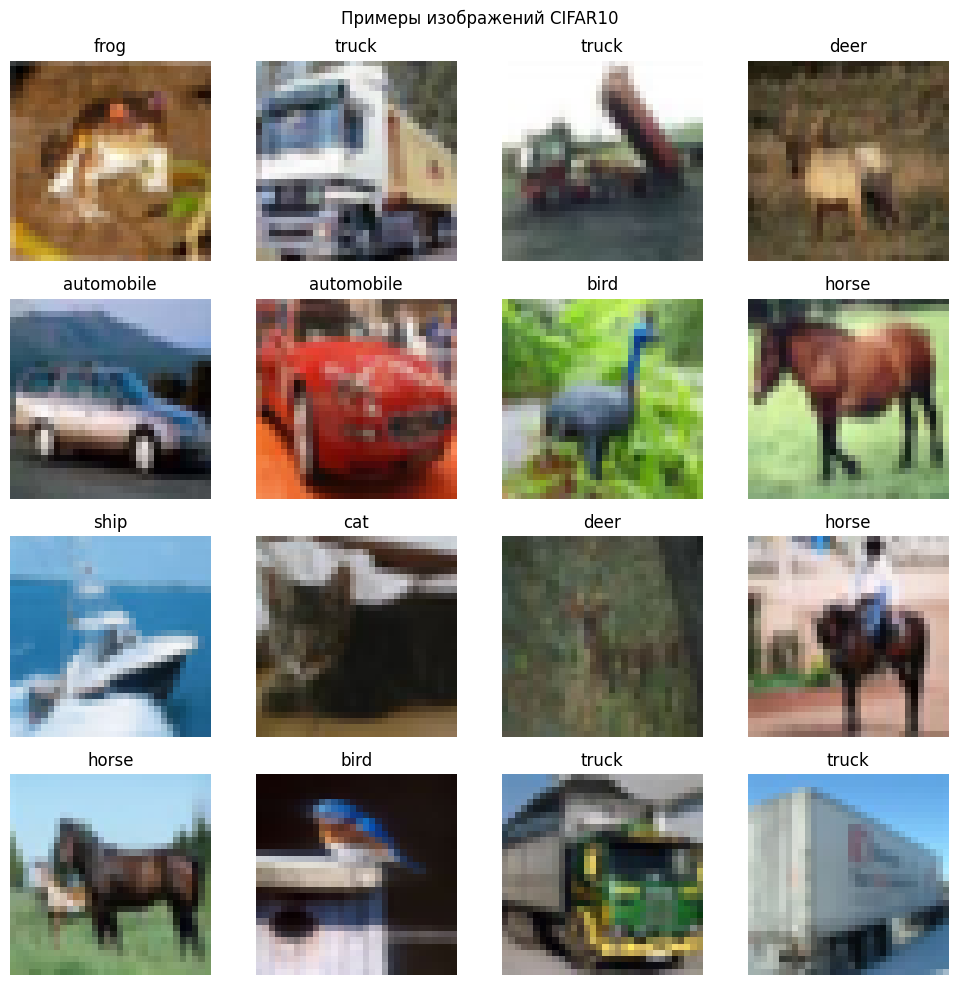

In [5]:
def plot_cifar10(dataset):
    size = 4
    fig, axes = plt.subplots(size, size, figsize=(10, 10))
    fig.suptitle("Примеры изображений CIFAR10")

    for i in range(size):
        for j in range(size):
            index = i * size + j
            axes[i, j].imshow(dataset.data[index], cmap=plt.cm.binary)
            axes[i, j].axis('off')
            axes[i, j].set_title(dataset.classes[dataset.targets[index]], )
    plt.tight_layout()
    plt.show()


plot_cifar10(train_dataset)

## Архитектура свёрточной нейронной сети (VGG-16 для CIFAR-10)

Модель представляет собой адаптированный вариант VGG-16, где сохранена оригинальная глубина сети, но уменьшены размеры полносвязной части (так как входные изображения имеют размер 32×32).
Архитектура состоит из пяти сверточных блоков, глобального усредняющего пуллинга и компактного классификатора.

**1. Входные данные**

    Формат: RGB-изображениеэ
    Размер: 3 × 32 × 32

**2. Сверточная часть (features)**

Каждый блок содержит несколько последовательных операций:

    Conv2d(3×3, padding=1, bias=False)
    BatchNorm2d
    ReLU

В конце каждого блока — MaxPool2d(2×2) и Dropout2d(p=0.1)

Структура блоков (согласно VGG-16):

**Block 1**

*    Conv(3→64)
*    Conv(64→64)
*    MaxPool → Dropout
**Выход**: 64 × 16 × 16

**Block 2**

*    Conv(64→128)
*    Conv(128→128)
*    MaxPool → Dropout
**Выход**: 128 × 8 × 8

**Block 3**

*    Conv(128→256)
*    Conv(256→256)
*    Conv(256→256)
*    MaxPool → Dropout
**Выход**: 256 × 4 × 4

**Block 4**

*    Conv(256→512)
*    Conv(512→512)
*    Conv(512→512)
*    MaxPool → Dropout
**Выход**: 512 × 2 × 2

**Block 5**

*    Conv(512→512)
*    Conv(512→512)
*    Conv(512→512)
*    MaxPool → Dropout
**Выход**: 512 × 1 × 1

**3. Пуллинг**

Используется адаптивное усреднение:

    AdaptiveAvgPool2d(output_size = 1×1)


Это гарантирует фиксированный выход независимо от размера входного изображения.

Выходной тензор: 512 × 1 × 1

После Flatten → вектор длины 512.

**4. Классификатор**

Компактная версия (уменьшенные FC-layers):

*    Linear(512 → 256)
*    ReLU
*    Dropout(p=0.6)
*    Linear(256 → 10)

**Выход**: логиты 10 классов CIFAR-10.

**5. Размеры карт признаков**

    Вход:             3 × 32 × 32
    Block 1 (pool):   64 × 16 × 16
    Block 2 (pool):  128 ×  8 ×  8
    Block 3 (pool):  256 ×  4 ×  4
    Block 4 (pool):  512 ×  2 ×  2
    Block 5 (pool):  512 ×  1 ×  1
    AdaptivePool →   512


In [6]:
VGG16_CFG = [
    64, 64, 'M',
    128, 128, 'M',
    256, 256, 256, 'M',
    512, 512, 512, 'M',
    512, 512, 512, 'M']

class VGG16_CIFAR(nn.Module):
    def __init__(self, cfg=VGG16_CFG, num_classes=10, batch_norm=True, dropout_fc=0.6):
        super().__init__()
        self.features = self._make_layers(cfg, batch_norm)
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_fc),
            nn.Linear(256, num_classes)
        )
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)            # [batch, 512, 1, 1]
        x = torch.flatten(x, 1)        # [batch, 512]
        x = self.classifier(x)
        return x

    def _make_layers(self, cfg, batch_norm):
        layers = []
        in_channels = 3
        for v in cfg:
            if v == 'M':
                layers += [
                  nn.MaxPool2d(kernel_size=2, stride=2),
                  nn.Dropout2d(p=0.1)
                ]
            else:
                conv = nn.Conv2d(in_channels, v, kernel_size=3, padding=1, bias=False)
                if batch_norm:
                    layers += [conv, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
                else:
                    layers += [conv, nn.ReLU(inplace=True)]
                in_channels = v
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

*   CrossEntropyLoss - функция потерь для задачи классификации
*   Оптимизатор SGD (Stochastic Gradient Descent) — стохастический градиентный спуск
*   Scheduler StepLR — планировщик изменения скорости обучения.Каждые 10 эпох (step_size=10) уменьшает learning rate в 0.5 раза (gamma=0.5). Это помогает модели лучше сходиться: сначала она быстро учится, потом делает более аккуратные шаги.

In [7]:
model = VGG16_CIFAR().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

## Обучение модели

In [8]:
train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    t0 = time.time()

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    model.eval()
    t_loss = 0.0
    t_correct = 0
    t_total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            t_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            t_total += targets.size(0)
            t_correct += predicted.eq(targets).sum().item()

    test_loss = t_loss / t_total
    test_acc = 100. * t_correct / t_total
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    scheduler.step()

    print(f"Эпоха {epoch:02d}/{num_epochs} | train_loss: {epoch_loss:.4f} | train_acc: {epoch_acc:5.2f}% | test_acc: {test_acc:5.2f}% | time: {time.time()-t0:4.1f}s")

print("Training finished.")

Эпоха 01/40 | train_loss: 1.8820 | train_acc: 26.21% | test_acc: 41.35% | time: 29.6s
Эпоха 02/40 | train_loss: 1.4832 | train_acc: 44.90% | test_acc: 54.56% | time: 29.0s
Эпоха 03/40 | train_loss: 1.2421 | train_acc: 55.60% | test_acc: 62.95% | time: 27.5s
Эпоха 04/40 | train_loss: 1.0817 | train_acc: 61.88% | test_acc: 70.35% | time: 28.1s
Эпоха 05/40 | train_loss: 0.9579 | train_acc: 66.63% | test_acc: 71.14% | time: 29.2s
Эпоха 06/40 | train_loss: 0.8690 | train_acc: 70.17% | test_acc: 75.65% | time: 28.4s
Эпоха 07/40 | train_loss: 0.7937 | train_acc: 73.21% | test_acc: 75.56% | time: 29.4s
Эпоха 08/40 | train_loss: 0.7341 | train_acc: 75.39% | test_acc: 78.37% | time: 29.3s
Эпоха 09/40 | train_loss: 0.6792 | train_acc: 77.34% | test_acc: 80.73% | time: 29.4s
Эпоха 10/40 | train_loss: 0.6299 | train_acc: 79.01% | test_acc: 80.28% | time: 30.9s
Эпоха 11/40 | train_loss: 0.5456 | train_acc: 81.89% | test_acc: 83.84% | time: 29.4s
Эпоха 12/40 | train_loss: 0.5136 | train_acc: 82.77% |

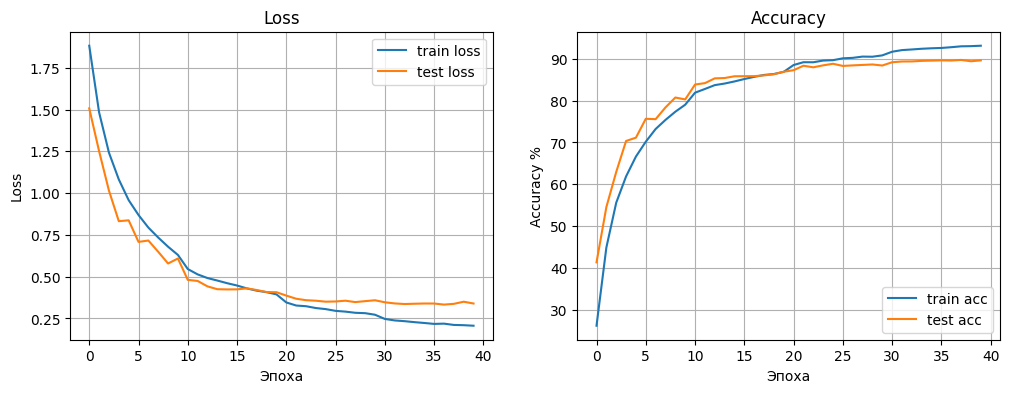

In [9]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.xlabel('Эпоха'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(train_accs, label='train acc')
plt.plot(test_accs, label='test acc')
plt.xlabel('Эпоха'); plt.ylabel('Accuracy %'); plt.legend(); plt.grid(True)
plt.title('Accuracy')

plt.show()

## Тестирование модели

In [10]:
def test(data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # градиенты не нужны
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    avg_loss = total_loss / total
    accuracy = correct / total

    print(f"loss: {avg_loss:.4f}, accuracy: {accuracy:.4f}")

In [11]:
test(test_loader)

loss: 0.3393, accuracy: 0.8961
